# Signal To Image Converter

In [1]:
import os
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from sklearn.model_selection import train_test_split

### 0. Load Dataset

In [2]:
labels = ['AF', 'N']

fs = 250

type_ = 'cnn' # pilih 'cnn' atau 'pure' untuk mengganti jenis data

In [3]:
dataset_folder = 'dataset/'
filenames = []
for filename in os.listdir(dataset_folder):
    if filename.find("_all") > -1 :
        filenames.append(filename)
        
filenames

['test_all-v2.csv',
 'test_all.csv',
 'test_all_Conv_AE.csv',
 'train_all-v2.csv',
 'train_all.csv',
 'train_all_Conv_AE.csv']

- read dataset

In [4]:
train_df = []
test_df = []

if type_ == 'cnn' :
    train_df = pd.read_csv(dataset_folder + "train_all_Conv_AE.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all_Conv_AE.csv", header=None)
elif type_ == 'pure' :
    train_df = pd.read_csv(dataset_folder + "train_all.csv", header=None)
    test_df = pd.read_csv(dataset_folder + "test_all.csv", header=None)

## 1. Dataset Augmentation

In [5]:
ecg_df = pd.concat([train_df, test_df])

train_df = []
test_df = []

In [6]:
ecg_df[600]=ecg_df[600].astype(int)
equilibre=ecg_df[600].value_counts()

print(equilibre)

1    30000
0    30000
Name: 600, dtype: int64


In [7]:
# sampling and resampling dataset

from sklearn.utils import resample
n_samples = 30000 
random_states = [123, 124]

dfs = []

for i in range(len(equilibre)):
    dfs.append(ecg_df[ecg_df[600]==i])
    dfs[i]=resample(dfs[i],replace=True,n_samples=n_samples,random_state=random_states[i])

ecg_df=pd.concat(dfs)

In [8]:
ecg_df[600]=ecg_df[600].astype(int)
equilibre=ecg_df[600].value_counts()

print(equilibre)

1    30000
0    30000
Name: 600, dtype: int64


## Split dataset

In [9]:
y = ecg_df.iloc[:,600].values
X = ecg_df.iloc[:,:600].values

### 2. Convert Signal Sequence to Image

In [12]:
def sequence_to_img(data):
    fig = Figure(figsize=(8, 8), dpi=28)
    canvas = FigureCanvasAgg(fig)

    ax = fig.add_subplot(111)
    ax.plot(data[0])
    ax.plot(data[1])
    ax.set_ylim(0,1)
    ax.axis('off')
    ax.margins(0)
    fig.tight_layout(pad=0)

    canvas.draw()
    buf = canvas.buffer_rgba()
    img = np.asarray(buf)[:, :, :3]
    return img

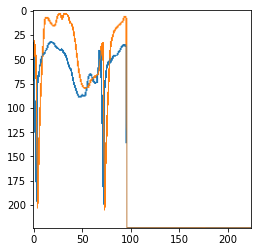

In [13]:
img = sequence_to_img(np.reshape(X[0], (2, 300)))
plt.imshow(img)

In [14]:
import matplotlib
matplotlib.__version__

'3.3.1'

- transform Train image to feature using VGG16

In [12]:
images = []

print("----- Signal to Image -------")
for i in range(len(X)):
    signal = np.reshape(X[i], (2, 300))
    img = sequence_to_img(signal)
    
    images.append(img)
    
    if i % 500 == 0:
        tm = datetime.datetime.now().strftime("%H:%M:%S")
        print('[%s] - finish processing %d sample' % (tm, i))

----- Signal to Image -------
[10:14:48] - finish processing 0 sample
[10:15:08] - finish processing 500 sample
[10:15:30] - finish processing 1000 sample
[10:15:53] - finish processing 1500 sample
[10:16:15] - finish processing 2000 sample
[10:16:34] - finish processing 2500 sample
[10:16:54] - finish processing 3000 sample
[10:17:14] - finish processing 3500 sample
[10:17:34] - finish processing 4000 sample
[10:17:55] - finish processing 4500 sample
[10:18:16] - finish processing 5000 sample
[10:18:36] - finish processing 5500 sample
[10:18:55] - finish processing 6000 sample
[10:19:15] - finish processing 6500 sample
[10:19:34] - finish processing 7000 sample
[10:19:54] - finish processing 7500 sample
[10:20:15] - finish processing 8000 sample
[10:20:36] - finish processing 8500 sample
[10:20:55] - finish processing 9000 sample
[10:21:15] - finish processing 9500 sample
[10:21:35] - finish processing 10000 sample
[10:21:53] - finish processing 10500 sample
[10:22:13] - finish proces

- save image and target data as compresed numpy array

In [13]:
#np.savez_compressed('dataset/X_image', X=images)

In [14]:
#np.savez_compressed('dataset/y_target', y=y)

In [ ]:
part = 5
diff = int(len(X)//part)
for i in range(part):
    start = i*diff
    stop = (i+1)*diff
    print("Save compressed matrix : id %d to %d in X_image_%d.npz" % (start, stop, i))
    np.savez_compressed('dataset/X_image_%d' % i, X=images[start : stop])
    np.savez_compressed('dataset/y_target_%d' % i, y=y[start : stop])